<a href="https://colab.research.google.com/github/DzhynHo/SI_2026/blob/main/Laboratorium3_21279.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Biblioteka numpy ułatwia pracę z macierzami i wielowymiarowymi tabelami.
import numpy as np
# Biblioteka Tensorflow posłuży nam do zbudowanie modelu
import tensorflow as tf
# Biblioteka opencv-python - biblioteka typu open source do przetwazanie obrazu i uczenia maszyny
import cv2
#Wizualizacja danych.
import matplotlib.pyplot as plt
# TensorFlow zawiera dostawcę danych dla MNIST, z którego będziemy korzystać.
import tensorflow_datasets as tfds


In [3]:
# tfds.load w rzeczywistości ładuje zestaw danych(lub pobiera, a następnie ładuje, jeśli używasz go po raz pierwszy)
# w naszym przypadku interesuje nas MNIST; nazwa zbioru danych jest jedynym obowiązkowym argumentem
# istnieją inne argumenty, które możemy określicz i które moga nam się przydać
# with_info - True dostarczy nam również krotkę zawierającą informacje o wersji, funkcjach, liczbie próbek
# wykorzystamy te informacje nieco poniżej i zapiszemy je w mnist_info
# as_supervised = True załaduje zestaw danych w strukturze 2-krotkowej (wejście,
# alternatywnie, as_supervised - False, zwróci słownik
# oczywiście wolimy, aby nasze dane wejściowe i cele były oddzielone
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

# Po załadowaniu zestawu danych możemy łatwo wyodrębnić zestaw danych szkoleniowyc
# i testowych z utworzonymi referencjami
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# Domyślnie TF ma zestawy danych treningowych i testowych, ale nie ma zestawów walidacyjnych
# dlatego musimy go samodzielnie podzielić
# zaczynamy od zdefiniowania liczby próbek walidacyjnych jako % próbek trenujących
# tutaj również używamy mnist_info (nie musimy liczyć obserwacji)
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples

# sparsujmy to na liczbę całkowitą, ponieważ liczba zmiennoprzecinkowa może po drodze spowodować błąd
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

# zapiszmy też liczbę próbek testowych w dedykowanej zmiennej (zamiast używać mnist_info)
num_test_samples = mnist_info.splits['test'].num_examples

# jeszcze raz parsujemy na liczbę całkowitą (zamiast domyślnej liczby zmiennoprzecinkowej)
num_test_samples = tf.cast(num_test_samples, tf.int64)



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.HPTYJM_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.HPTYJM_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [4]:
# należy znormalizować nasze dane, aby wynik był bardziej stabilny numerycznie
# dane wejściowe muszą być w zakresie liczbowym od 0 do 1
# zdefiniujmy funkcję o nazwie: scale, która pobierze obraz MNIST i jego etykietę

def scale(image, label):
# potrzebujemy wartości zmiennoprzecinkowej float
   image = tf.cast(image, tf.float32)
# ponieważ możliwe wartości dla wejść to od 0 do 255 (256 różnych odcieni szarości)
# jeśli podzielimy każdy element przez 255, otrzymamy pożądany wynik:
# wszystkie elementy będą znajdować się w przedziale od 0 do 1
   image /= 255.
   return image, label

# metoda .map () pozwala nam zastosować niestandardową transformację do danego zbioru danych
# już zdecydowaliśmy, że otrzymamy dane walidacyjne z mnist_train, więc
scaled_train_and_validation_data = mnist_train.map(scale)

# na koniec normalizujemy i grupujemy dane testowe
# aby miały taką samą wielkość jak dane trenjące i walidacyjne
# nie ma potrzeby ich mieszania, ponieważ nie będziemy trenować na danych testowych
# będzie to pojedyncza partia równa wielkości danych testowych
test_data = mnist_test.map(scale)


In [5]:
# ten parametr BUFFER_SIZE jest tutaj w przypadkach, gdy mamy do czynienia z ogromnymi zbiorami danych
# wtedy nie możemy przetasować całego zestawu danych za jednym razem,
# ponieważ nie możemy zmieścić go w pamięci
# więc zamiast tego TF przechowuje w pamięci tylko BUFFER_SIZE próbki na raz i tasuje je
# if BUFFER_SIZE = 1 => żadne tasowanie nie nastąpi
# if BUFFER_SIZE> = liczba próbek => tasowanie jest jednolite
# BUFFER_SIZE pomiędzy - optymalizacja obliczeniowa w celu przybliżenia jednolitego tasowania
BUFFER_SIZE = 1000

# jest łatwo dostępna metoda shuffle i musimy tylko określić rozmiar bufora
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

# po przeskalowaniu i przetasowaniu danych możemy przystąpić do faktycznego wyodrębniania
# danych trenujących i walidacyjnych
# nasze dane walidacyjne byłyby równe 10% zbioru uczącego, który już obliczyliśmy
# używamy metody .take(), aby pobrać tyle próbek
# na koniec tworzymy partię o wielkości równej całkowitej liczbie próbek walidacyjnych
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)

# podobnie train_data to wszystko inne, więc pomijamy tyle próbek
# ile jest w zbiorze danych walidacyjnych
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [6]:
# zmienna określająca wielkość partii podawanej podczas trenowania
BATCH_SIZE = 100

# tworzymy partie danych treningowych
# jest to bardzo pomocne podczas treningu, ponieważ możęmy iterować po różnych partiach
train_data = train_data.batch(BATCH_SIZE)

validation_data = validation_data.batch(num_validation_samples)

test_data = test_data.batch(num_test_samples)

# pobieramy i iterujemy partię walidacyjną (jest to jedyna partia)
# ponieważ as_supervized = True, mamy strukturę składającą się z dwóch krotek
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [7]:
input_size = 784 # 28 x 28 pikseli
output_size = 10 # 10 różnych cyfr

# Użyjemy tego samego rozmiaru ukrytej warstwy dla obu ukrytych warstw. Nie jest to konieczne.
hidden_layer_size = 50

#MODEL
model = tf.keras. Sequential([

# Pierwsza warstwa to warstwa wejściowa.
# Każda próbka ma wymiary 28x28x1 pikseli, dlatego jest to tensor rozmiaru 3.
# Ponieważ to nie jest jeszcze CNN, nie wiemy, jak wprowadzić takie dane wejściowe
# do naszej sieci, więc musimy spłaszczyć obrazy.
# istnieje wygodna warstwa „Flatten”, która po prostu pobiera nasz tensor 28x28x1
# i porządkuje go w (None,) lub (28x28x1,)=(784,)
# to pozwala nam faktycznie stworzyć sieć neuronową typu feed forward
   tf.keras.layers.Flatten(input_shape=(28, 28, 1)), # input layer, warstwa wejściowa

# tf.keras.layers.Dense jest w zasadzie implementacją modelu liniowego:
# y = xw + b czyli output = activation(dot(input, weight) + bias)
# wymaga kilku argumentów, ale najważniejsze dla nas to hidden_layer_size i funkcja aktywacji
tf.keras.layers.Dense(hidden_layer_size, activation='relu'), # warstwa ukryta
tf.keras.layers.Dense(hidden_layer_size, activation='relu'), # warstwa ukryta

# ostatnia warstwa nie jest inna, po prostu upewniamy się,
# że aktywujemy ją za pomocą softmax, która daje nam rozkład prawdopodobieństwa
# i ma rozmiar output_size
tf.keras.layers.Dense(output_size, activation='softmax' ) # output layer

])

# określamy na końcu funkcję optymalizacji, którego chcielibyśmy użyć,
# funkcja straty, # oraz metryki, które chcemy uzyskać w każdej epocy uczenia
model. compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy' ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# ustawiamy ilość epok
NUM_EPOCHS = 30

# ustaw mechanizm wczesnego zatrzymywania, który ochroni nasz model przed przetrenowaniem
# ustawmy patience=2, aby być nieco tolerancyjnym na losowe wzrosty strat walidacji
early_stopping = tf.keras.callbacks. EarlyStopping(patience=2)

# dopasowujemy model, określając dane treningowe, łączną liczbę epok
# oraz dane walidacyjne, które właśnie stworzyliśmy, w formacie: (INPUTS, TARGETS),

model.fit(train_data, # dane wejściowe trenujące
          epochs=NUM_EPOCHS, # maksymalna ilość epok gdyby wczesne zatrzymanie nie zadziałało
          callbacks=[early_stopping], # mechanizm "early stopping" - zapobieganie przetrenowaniu
          validation_data=(validation_inputs, validation_targets), # dane walidacyjne
          verbose = 1 # sposób pokazania treningu modelu
           )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8808 - loss: 0.4181 - val_accuracy: 0.9362 - val_loss: 0.2180
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9478 - loss: 0.1824 - val_accuracy: 0.9505 - val_loss: 0.1687
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9601 - loss: 0.1399 - val_accuracy: 0.9570 - val_loss: 0.1495
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9668 - loss: 0.1152 - val_accuracy: 0.9607 - val_loss: 0.1321
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9721 - loss: 0.0967 - val_accuracy: 0.9602 - val_loss: 0.1350
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9754 - loss: 0.0831 - val_accuracy: 0.9622 - val_loss: 0.1254
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9790 - loss: 0.0713 - val_accuracy: 0.9652 - val_loss: 0.1166
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9811 - loss: 0.0636 - val_accur

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)
# możemy zastosować estetyczne formatowanie
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9631 - loss: 0.1269
Test loss: 0.13. Test accuracy: 96.31%


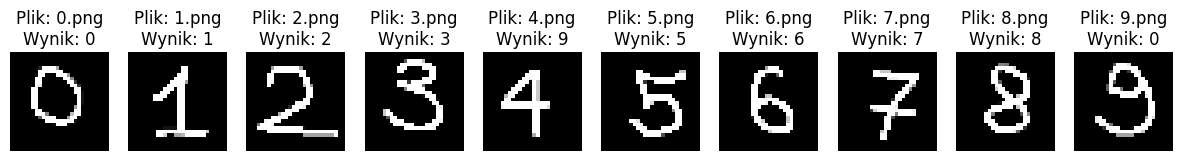

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

file_names = [f"{i}.png" for i in range(10)]

plt.figure(figsize=(15, 5))

for i, name in enumerate(file_names):
    path = f'/content/liczby/{name}'

    if os.path.exists(path):

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, (28, 28))

        img_final = img_resized.astype('float32') / 255
        img_final = np.reshape(img_final, (1, 28, 28, 1))

        prediction = model.predict(img_final, verbose=0)
        result = np.argmax(prediction)

        plt.subplot(1, 10, i + 1)
        plt.imshow(img_resized, cmap='gray')
        plt.title(f"Plik: {name}\nWynik: {result}")
        plt.axis('off')
    else:
        print(f"Brak pliku: {name}")

plt.show()